# Insurance como tercer caso de auditoría
Tarea 4.1. Autor: Jorge Josué Flores González.
Proyecto construido con Medical Cost Personal, uno de los datasets publicados en la sección compartida 4.1/4.2. Esta elección se documenta como interpretación del material y orientación de compañeros, no como notebook original del profesor. Objetivo: predecir charges para estudiar errores de estimación de costos; no tomar decisiones sobre cobertura ni atención. Se audita por región, elegida antes de entrenar. La unidad monetaria y el período de los cargos deben confirmarse con la documentación del dataset antes de una aplicación real.


In [1]:
%matplotlib inline
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score
RANDOM_STATE=42
archivo=Path('datos/insurance.csv')
if not archivo.exists():
    from google.colab import files
    subidos=files.upload()
    archivo=Path('insurance.csv')
df=pd.read_csv(archivo)
print('Filas originales:',len(df),'Duplicados exactos:',df.duplicated().sum())
# Una fila idéntica no debe cruzar entrenamiento y prueba.
df=df.drop_duplicates().reset_index(drop=True)
print('Filas utilizadas:',len(df),'Nulos:',df.isna().sum().sum())


Filas originales: 1338 Duplicados exactos: 1
Filas utilizadas: 1337 Nulos: 0


## Partición y modelos
Se usan age, sex, bmi, children, smoker y region; charges se excluye de los predictores. La disponibilidad de estas variables antes del costo es un supuesto del ejercicio, no está verificada con fechas de captura. Una partición aleatoria 75/25 con semilla42 sirve a ambos modelos; no se estratifica un objetivo continuo. La imputación, codificación y escala se ajustan dentro del Pipeline solo con entrenamiento. No se optimizan hiperparámetros. No existen identificadores de pacientes que permitan demostrar independencia por persona.


In [2]:
numericas=['age','bmi','children']
categoricas=['sex','smoker','region']
X=df[numericas+categoricas]; y=df['charges']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=RANDOM_STATE)
assert not set(X_train.index)&set(X_test.index)
assert 'charges' not in X.columns
prepro=ColumnTransformer([
 ('numericas',Pipeline([('imputar',SimpleImputer(strategy='median')),('escalar',StandardScaler())]),numericas),
 ('categoricas',Pipeline([('imputar',SimpleImputer(strategy='most_frequent')),('codificar',OneHotEncoder(handle_unknown='ignore'))]),categoricas)])
modelos={'Referencia':DummyRegressor(strategy='mean'),'Lineal':Pipeline([('prepro',prepro),('modelo',LinearRegression())])}
filas=[]; predicciones={}
for nombre,modelo in modelos.items():
    modelo.fit(X_train,y_train)
    pred=modelo.predict(X_test); predicciones[nombre]=pred
    mse=mean_squared_error(y_test,pred)
    filas.append(dict(modelo=nombre,MSE=mse,RMSE=np.sqrt(mse),R2=r2_score(y_test,pred),R2_train=modelo.score(X_train,y_train)))
tabla=pd.DataFrame(filas)
print(tabla.to_string(index=False))


    modelo          MSE         RMSE        R2  R2_train
Referencia 1.735269e+08 13172.959408 -0.003569  0.000000
    Lineal 3.528392e+07  5940.027169  0.795940  0.729749


## Evidencia para la Skill
Se conserva cada predicción de prueba para recalcular MSE, RMSE y R². La alerta de disparidad usa |RMSE del grupo − RMSE global| / RMSE global > 0.20, con mínimo20 casos por grupo. Es un umbral exploratorio elegido por una desviación relativa de una quinta parte; no es un estándar de equidad. Si falta soporte, el resultado es NO SE PUEDE DETERMINAR. Se mantiene el umbral aunque aparezcan alertas.


    grupo  n        RMSE  brecha_relativa resultado
northeast 95 6184.419436         0.041143      PASA
northwest 71 6308.009480         0.061950      PASA
southeast 95 6210.564049         0.045545      PASA
southwest 74 4789.106563         0.193757      PASA


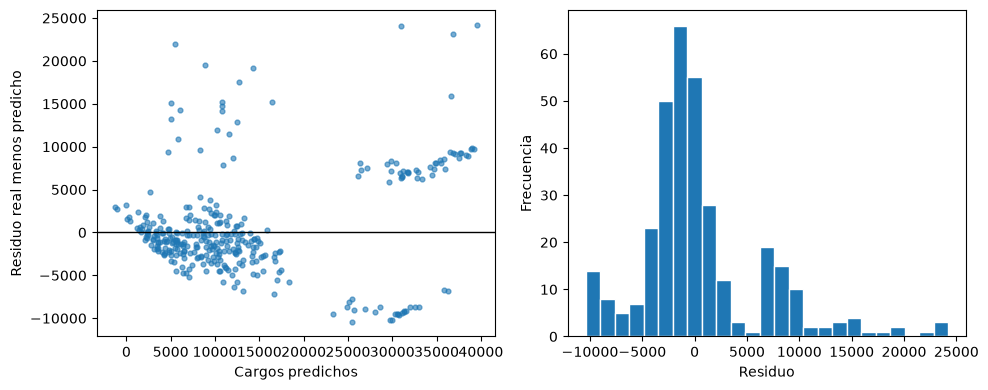

In [3]:
pred=predicciones['Lineal']
evidencia=pd.DataFrame({'indice':X_test.index,'y_true':y_test.to_numpy(),'y_pred':pred,'subgrupo':X_test.region.to_numpy()})
evidencia.to_csv('predicciones_insurance.csv',index=False)
rmse_global=float(np.sqrt(mean_squared_error(y_test,pred)))
grupos=[]
for nombre,g in evidencia.groupby('subgrupo'):
    rmse=float(np.sqrt(mean_squared_error(g.y_true,g.y_pred)))
    brecha=abs(rmse-rmse_global)/rmse_global if rmse_global else (0.0 if rmse==0 else None)
    estado='NO SE PUEDE DETERMINAR' if len(g)<20 or brecha is None else ('FALLA' if brecha>.20 else 'PASA')
    grupos.append(dict(grupo=nombre,n=len(g),RMSE=rmse,brecha_relativa=brecha,resultado=estado))
print(pd.DataFrame(grupos).to_string(index=False))
Path('metricas_insurance.json').write_text(json.dumps({'tabla':tabla.to_dict(orient='records'),'subgrupos':grupos,'n_train':len(X_train),'n_test':len(X_test)},indent=2))
residuos=y_test.to_numpy()-pred
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(pred,residuos,s=12,alpha=.6); axes[0].axhline(0,color='black',lw=1)
axes[0].set(xlabel='Cargos predichos',ylabel='Residuo real menos predicho')
axes[1].hist(residuos,bins=25,edgecolor='white'); axes[1].set(xlabel='Residuo',ylabel='Frecuencia')
plt.tight_layout(); plt.savefig('residuos_insurance.png',dpi=150); plt.show()


## Límites
La muestra pública no es una validación de costos actuales ni de pacientes de una institución. La regresión lineal puede omitir interacciones y producir valores negativos; comprobar esto en las predicciones y no ocultarlo. El análisis por región no demuestra ausencia de disparidad en otros atributos. No extrapolar fuera de los rangos de entrenamiento ni usar el resultado para negar cobertura, fijar primas o decidir atención. Este caso alimenta la auditoría de la tarea4.1 y no sustituye la herramienta completa de la4.2.
